In [2]:
from pathlib import Path
import importlib
import logging
import sys
import os

logging.basicConfig(
    format="%(levelname)s: %(message)s", stream=sys.stdout, level=logging.INFO
)
logger = logging.getLogger("__notebook__")

# Loading markov model directory as module into jupyter notebook
module_dir = Path(os.getcwd()).parent.resolve()
data_dir = module_dir / "data"

logger.info(f"module directory: {module_dir}")

if str(module_dir) not in sys.path:
    sys.path.insert(1, str(module_dir))
else:
    logger.info("Module path already inserted into system paths")

try:
    from model import markov_chain
    from model import probabilistic_analysis as psa
    from model import visualization
    from model import constants
    from model import utils

    # to apply changes in modules
    importlib.reload(markov_chain)
    importlib.reload(psa)
    importlib.reload(visualization)
    importlib.reload(constants)
    importlib.reload(utils)
except ModuleNotFoundError as e:
    logger.error(f"Unable to import module: {e.msg}")

INFO: module directory: /home/mohammad/projects/Thesis/hemophilia


In [3]:
# Model inputs
base_sample_size = 512  # simulated sample final count follows N * (D + 2)
short_steps = constants.SHORT_TERM_CYCLE_COUNTS
ssp = constants.START_SIMULATION_AGE_IN_WEEK

# Loading states name from excel sheet is deprecated, now on only generate within the code blocks
start_state = constants.START_STATE
primary_states = constants.PRIMARY_STATES
secondary_states = constants.SECONDARY_STATES
# NOTE:
# Transition matrix is dynamically generated through the *_psa functions as they sample from abr values
# To change in states need to update the psa worker functions as well to support new model schema
# NOTE:
# Newly suggested model structure:               switch
#                   [Healthy]                    ------>                     [Arthropathy]
#        |              |              |                           |              |              |
# [LT Bleeding] | [Hemarthrosis] | [Bleeding]               [LT Bleeding] | [Hemarthrosis] | [Bleeding]
#    |                  |                                          |
# [DEATH]         [Arthropathy]                                 [DEATH]
chains = {"primary": (primary_states, {}), "secondary": (secondary_states, {})}


# Define switch conditions
def arthropathy_switch_condition(step: int, state: str, chain: str, **kwargs) -> bool:
    """Determine if a switch to the secondary chain should occur based on the Arthropathy state."""
    return state == "Arthropathy" and chain == "primary"


switch_conditions = {"secondary": arthropathy_switch_condition}

In [4]:
weights = [utils.cal_body_weight(n, b=ssp) for n in range(short_steps)]
# Short term simulation
on_demand_inputs, on_demand_outputs = psa.markov_chains_psa_wrapper(
    strategy="on_demand",
    n_samples=base_sample_size,
    chains=chains,
    start_chain="primary",
    start_state="Healthy",
    steps=short_steps,
    switch_conditions=switch_conditions,
)

prophylaxis_inputs, prophylaxis_outputs = psa.markov_chains_psa_wrapper(
    strategy="prophylaxis",
    n_samples=base_sample_size,
    chains=chains,
    start_chain="primary",
    start_state="Healthy",
    steps=short_steps,
    switch_conditions=switch_conditions,
)

In [5]:
import pandas as pd
import numpy as np


def truncate_weights_at_death(sequences: list["str"]):
    death_indices = [
        i
        for i, state in enumerate(sequences)
        if state
        and any(
            "death" in str(s).lower()
            for s in (state if isinstance(state, (list, tuple)) else [state])
        )
    ]

    if death_indices:
        # Use the first death occurrence
        death_index = death_indices[0]
        return weights[: death_index + 1]  # Include the death state

    # If no death found, return full weights
    return weights


cols = [
    "regimes",
    "abrs",
    "factors",
    "qalys",
    "costs",
    "bleeds",
    "annual_factors",
    "annual_costs",
    "is_arthropathy",
    "is_dead",
    "sequences",
    "weights",
]

od_df = pd.DataFrame(
    data={
        "regimes": "on_demand",
        "abrs": [op["abr"] for op in on_demand_inputs],
        "factors": [op.total_factor_use for op in on_demand_outputs],
        "qalys": [op.qaly for op in on_demand_outputs],
        "costs": [op.total_factor_costs for op in on_demand_outputs],
        "annual_factors": [op.annual_factor_consumption for op in on_demand_outputs],
        "annual_costs": [op.annual_factor_costs for op in on_demand_outputs],
        "is_arthropathy": [
            True if "Arthropathy" in op.sequences else False for op in on_demand_outputs
        ],
        "is_dead": [
            True if "Death" in op.sequences else False for op in on_demand_outputs
        ],
        "sequences": [op.sequences for op in on_demand_outputs],
        "weights": [
            truncate_weights_at_death(op.sequences) for op in on_demand_outputs
        ],
    },
    columns=cols,
)

pro_df = pd.DataFrame(
    data={
        "regimes": "prophylaxis",
        "abrs": [op["abr"] for op in prophylaxis_inputs],
        "factors": [op.total_factor_use for op in prophylaxis_outputs],
        "qalys": [op.qaly for op in prophylaxis_outputs],
        "costs": [op.total_factor_costs for op in prophylaxis_outputs],
        "annual_factors": [op.annual_factor_consumption for op in prophylaxis_outputs],
        "annual_costs": [op.annual_factor_costs for op in prophylaxis_outputs],
        "is_arthropathy": [
            True if "Arthropathy" in op.sequences else False
            for op in prophylaxis_outputs
        ],
        "is_dead": [
            True if "Death" in op.sequences else False for op in prophylaxis_outputs
        ],
        "sequences": [op.sequences for op in prophylaxis_outputs],
        "weights": [
            truncate_weights_at_death(op.sequences) for op in prophylaxis_outputs
        ],
    },
    columns=cols,
)

od_df['mean_weight'] = od_df['weights'].apply(lambda x: np.array(x).mean())
od_df['person_year'] = od_df['weights'].apply(lambda x: len(x)/52)
pro_df['mean_weight'] = pro_df['weights'].apply(lambda x: np.array(x).mean())
pro_df['person_year'] = pro_df['weights'].apply(lambda x: round(len(x)/52, 2))

df = pd.concat([od_df, pro_df])

Text(0.5, 0, 'age (year)')

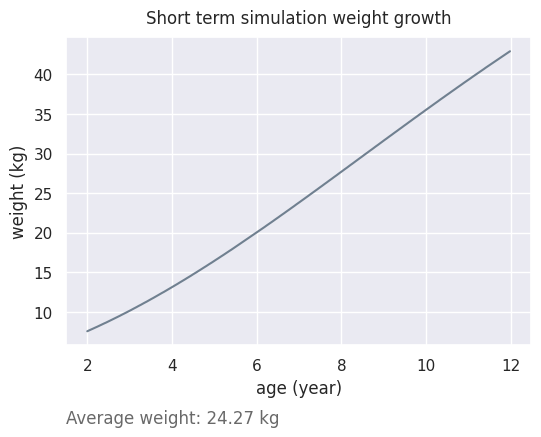

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

pairs: dict[int, float] = {(i + ssp): weight for i, weight in enumerate(weights)}
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
X = np.array(list(pairs.keys()))
Y = np.array(list(pairs.values()))
ax.plot([i / constants.WOY for i in X], Y, color="slategray")
ax.set_title("Short term simulation weight growth", pad=10)
ax.text(1.5, -4, f"Average weight: {round(np.mean(weights), 2)} kg", color="dimgray")
ax.set_ylabel("weight (kg)")
ax.set_xlabel("age (year)")

In [7]:
# ---- Debug cell ----
debug = False

# Graphs stores at outputs/figures/transitions
if debug:
    # on_demand simulation transition matrix graph
    for i, inputs in enumerate(np.random.choice(on_demand_inputs, size=5)):
        chains = inputs["chains"]
        primary_matrix = chains["primary"][1]
        secondary_matrix = chains["secondary"][1]
        visualization.visualize_transition_matrix(
            matrix=primary_matrix,
            states=primary_states,
            title=f"on-demand-primary-{int(round(inputs['abr'],0))}-{int(round(inputs['ajbr'], 0))}",
        )
        visualization.visualize_transition_matrix(
            matrix=secondary_matrix,
            states=secondary_states,
            title=f"on-demand-secondary-{int(round(inputs['abr'],0))}-{int(round(inputs['ajbr'], 0))}",
        )
    # prophylaxis simulation transition matrix graph
    for i, inputs in enumerate(np.random.choice(prophylaxis_inputs, size=5)):
        chains = inputs["chains"]
        primary_matrix = chains["primary"][1]
        secondary_matrix = chains["secondary"][1]
        visualization.visualize_transition_matrix(
            matrix=primary_matrix,
            states=primary_states,
            title=f"prophylaxis-primary-{int(round(inputs['abr'],0))}-{int(round(inputs['ajbr'], 0))}",
        )
        visualization.visualize_transition_matrix(
            matrix=secondary_matrix,
            states=secondary_states,
            title=f"prophylaxis-secondary-{int(round(inputs['abr'],0))}-{int(round(inputs['ajbr'], 0))}",
        )

In [8]:
# Value to report:
# Report no. of factor viii infusions [ ]
# Report annual cost of factor viii / kg [ ]
# Report annual joint hemorrhages [ ]
# Report no. of factor viii unit infused [√]
# Report no. of factor viii unit infused per kg [√]
# Report annual bleeding rate [√]
# Report quality adjusted life year [√]
# Report Incremental cost effectiveness ratio [√]
# Report Net monetary benefit [√]

In [32]:
SAMPLE_SIZE = len(on_demand_inputs)
DC = round((pro_df["costs"].mean() - od_df["costs"].mean()), 2)  # per patient
DQ = round((pro_df["qalys"].mean() - od_df["qalys"].mean()), 2)  # per patient
DC_TOTAL = round(pro_df["costs"].sum() - od_df["costs"].sum(), 2)
DQ_TOTAL = round(pro_df["qalys"].sum() - od_df["qalys"].sum(), 2)
# annual costs gained per patient
DC_ANNUAL = round(DC / (short_steps / constants.WOY), 2)
ICER = DC_TOTAL / DQ_TOTAL
ICER_ANNUAL = round(ICER / (short_steps / constants.WOY), 2)
LYG_TOTAL = round(pro_df["person_year"].sum() - od_df["person_year"].sum(), 2)
ICER_LTG = DC_TOTAL / LYG_TOTAL


# Net monetary benefits
NMB = round((constants.WTP_THRESHOLD * (DQ)) - (DC), 2)
# TODO:
# - Number of died patients are not rational, tune the model with accurate rate
# - Make sure the transitioning probability to arthropathy is valid
logger.info(
    f"""
    [Short Term]
    Simulation results for {int(short_steps/constants.WOY)} Years (2 - 13) | {SAMPLE_SIZE} samples included
    Number of simulations transitioned to chronic arthropathy: -> On Demand: {od_df["is_arthropathy"].sum()} - Prophylaxis: {pro_df["is_arthropathy"].sum()}
    Percentage of normal joints: On Demand: -> {round(1 - (od_df['is_arthropathy'].sum()/SAMPLE_SIZE), 2)}% - Prophylaxis: {round(1 - (pro_df['is_arthropathy'].sum()/SAMPLE_SIZE), 2)}%
    Number of patients died from life threating bleedings: -> On Demand: {od_df["is_dead"].sum()} - Prophylaxis: {pro_df['is_dead'].sum()}
    Mortality rate (deaths per 100 person-years): -> On Demand: {round(od_df["is_dead"].sum()/od_df['person_year'].sum() * 100, 2)} - Prophylaxis: {round(pro_df['is_dead'].sum()/pro_df['person_year'].sum() * 100, 2)}
    Life year gained: {LYG_TOTAL} years, per person {round(LYG_TOTAL / SAMPLE_SIZE, 2)} years
    
    [Model outputs]
    Annual bleeding rate:
    - On Demand: Mean (std) {int(od_df['abrs'].mean())} ({int(od_df['abrs'].std())}), Median {int(od_df['abrs'].median())}
    - Prophylaxis : Mean (std) {int(pro_df['abrs'].mean())} ({int(pro_df['abrs'].std())}), Median {int(pro_df['abrs'].median())}
    Note: prophylaxis on average reduces ABR about {1 - round(od_df['abrs'].mean()/ pro_df['abrs'].mean()/100, 2)}%
    
    Total factor consumption:
    - On Demand: {int(od_df['factors'].mean())} ({int(od_df['factors'].std())}) IU
    - Prophylaxis: {int(pro_df['factors'].mean())} ({int(pro_df['factors'].std())}) IU
    Note: consumptions increased by {round(pro_df['factors'].mean() / od_df['factors'].mean(), 2)} folds
    
    Annual factor consumption:
    - On Demand: {int(od_df['annual_factors'].mean())} ({int(od_df['annual_factors'].std())}) IU
    - Prophylaxis: {int(pro_df['annual_factors'].mean())} ({int(pro_df['annual_factors'].std())}) IU
    
    Annual factor consumption per kg:
    - On Demand: {int(od_df['annual_factors'].mean() / od_df['mean_weight'].mean())} IU
    - Prophylaxis: {int(pro_df['annual_factors'].mean() / pro_df['mean_weight'].mean())} IU
    
    Annual factor costs per kg:
    - On Demand: ${int(od_df['annual_costs'].mean() / od_df['mean_weight'].mean()):,}
    - Prophylaxis: ${int(pro_df['annual_costs'].mean() / pro_df['mean_weight'].mean()):,}
    
    Quality adjusted life year:
    - On Demand: Mean (std) {round(od_df['qalys'].mean(), 2)}, ({round(od_df['qalys'].std(), 2)}), Median {round(od_df['qalys'].median(), 2)}
    - Prophylaxis: Mean (std) {round(pro_df['qalys'].mean(), 2)}, ({round(pro_df['qalys'].std(), 2)}) | Median {round(pro_df['qalys'].median(), 2)}
    
    Conclusions:
    {DQ} qaly gained with ${DC:,} increase in cost of treatment, (Annually: ${DC_ANNUAL:,})
    Incremental cost effectiveness ratio: ${int(ICER):,} | ICER LYG: ${int(ICER_LTG):,}
    Willingness to pay threshold: ${round(constants.WTP_THRESHOLD, 2):,} {'>' if constants.WTP_THRESHOLD > ICER_ANNUAL else '<'} ${ICER_ANNUAL:,}
    Net monetary benefit: ${NMB}
    
    CUA: Intervention was {'' if NMB > 0 else 'not'} cost effective
    """
)

INFO: 
    [Short Term]
    Simulation results for 10 Years (2 - 13) | 11264 samples included
    Number of simulations transitioned to chronic arthropathy: -> On Demand: 6235 - Prophylaxis: 1151
    Percentage of normal joints: On Demand: -> 0.45% - Prophylaxis: 0.9%
    Number of patients died from life threating bleedings: -> On Demand: 3412 - Prophylaxis: 828
    Mortality rate (deaths per 100 person-years): -> On Demand: 3.65 - Prophylaxis: 0.76
    Life year gained: 14843.04 years, per person 1.32 years
    
    [Model outputs]
    Annual bleeding rate:
    - On Demand: Mean (std) 21 (20), Median 14
    - Prophylaxis : Mean (std) 3 (4), Median 2
    Note: prophylaxis on average reduces ABR about 0.94%
    
    Total factor consumption:
    - On Demand: 255390 (230914) IU
    - Prophylaxis: 969952 (196167) IU
    Note: consumptions increased by 3.8 folds
    
    Annual factor consumption:
    - On Demand: 25539 (23091) IU
    - Prophylaxis: 96995 (19616) IU
    
    Annual factor

INFO: 
    Bootstrapping model outputs to calculate ICER IQR and SD
    
INFO: 
    IQR: $26411.21
    


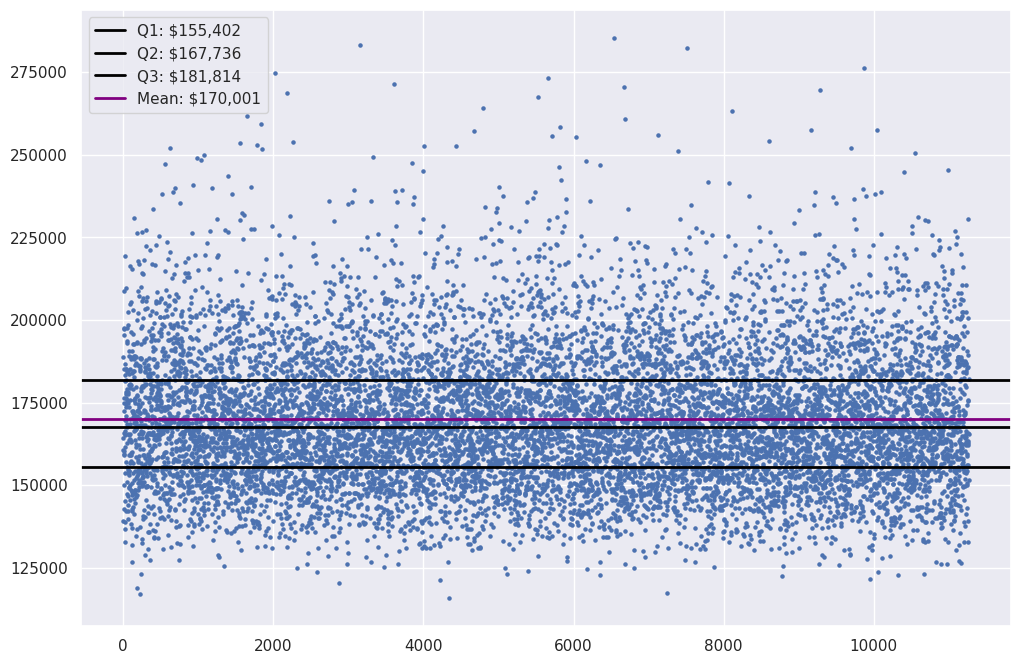

In [ ]:
logger.info(
    """
    Bootstrapping model outputs to calculate ICER IQR and SD
    """
)
ICERS = []
for i in range(SAMPLE_SIZE):
    od = od_df.sample(n=128)
    pro = pro_df.sample(n=128)
    dc = pro["costs"].sum() - od["costs"].sum()
    dq = pro["qalys"].sum() - od["qalys"].sum()
    if np.isfinite(dc) and np.isfinite(dq) and dq != 0:
        ICERS.append(dc / dq)
ICERS = np.array(ICERS)
pairs = [(i, y) for i, y in enumerate(ICERS)]
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.scatter(x=[i[0] for i in pairs], y=[i[1] for i in pairs], s=5)

Q1 = np.percentile(ICERS, 25).astype(float)
Q2 = np.percentile(ICERS, 50).astype(float)
Q3 = np.percentile(ICERS, 75).astype(float)
ICERS_MEAN = ICERS.mean()

ax.axhline(Q1, color="black", linewidth=2, label=f"Q1: ${int(Q1):,}")
ax.axhline(Q2, color="black", linewidth=2, label=f"Q2: ${int(Q2):,}")
ax.axhline(Q3, color="black", linewidth=2, label=f"Q3: ${int(Q3):,}")
ax.axhline(ICERS_MEAN, color="purple", linewidth=2, label=f"Mean: ${int(ICERS_MEAN):,}")

ax.legend()

logger.info(
    f"""
    IQR: ${(Q3 - Q1):.2f}
    """
)